1. Load & Explore Data

In [255]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [256]:
df=sns.load_dataset('titanic')
print("--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- DATASET SHAPE ---")
print(f"Rows {df.shape[0]} , columns {df.shape[1]}")

print("\n--- COLUMNS AND DATA TYPES ---")
print(df.dtypes)



--- FIRST 5 ROWS ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- DATASET SHAPE ---
Rows 891 , columns 15

--- COLUMNS AND DATA TYPES ---
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
p

In [257]:
print("\n--- STATISTICAL SUMMARY (Numerical) ---")
print(df.describe())

print("\n ---  Check Missing Values ---")
df.isnull().sum()

print("\n--- DUPLICATE ROWS COUNT ---")
print(df.duplicated().sum())


--- STATISTICAL SUMMARY (Numerical) ---
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

 ---  Check Missing Values ---

--- DUPLICATE ROWS COUNT ---
107


2. Data Cleaning

In [258]:
print("\n---  Remove duplicate records. ---")
print(df.drop_duplicates(inplace=True))

#Age → Median • Fare → Median • Embarked → Mode •


---  Remove duplicate records. ---
None


In [259]:
print("----Handle missing values: -----")
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(),inplace=True )
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True )


----Handle missing values: -----


C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_1256\1173822796.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_1256\1173822796.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

0      S
1      C
2      S
3      S
4      S
      ..
885    Q
887    S
888    S
889    C
890    Q
Name: embarked, Length: 784, dtype: str

In [260]:
print(df.drop(columns=['deck'],inplace=True))

None


3. Feature Engineering Create new features: 


In [261]:
print("---- Family Size")
df["FamilySize"] = df["sibsp"] + df["parch"] + 1
print(df['FamilySize'])



---- Family Size
0      2
1      2
2      1
3      2
4      1
      ..
885    6
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 784, dtype: int64


In [262]:
print("--- Chk pessenger Is alone")
df.loc[df['FamilySize']==1 , "alone"]==1

--- Chk pessenger Is alone


2      True
4      True
5      True
6      True
11     True
       ... 
882    True
883    True
887    True
889    True
890    True
Name: alone, Length: 446, dtype: bool

 4. Data Transformation

• Encode categorical variables (Sex, Embarked, Title). 

In [263]:
le=LabelEncoder()
df['sex']=df['sex'].map({"male":0,"female":1})
df["embarked"] = le.fit_transform(df["embarked"])

if 'Titel' in df.columns:
    df['Title']=le.fit_transform(df['Titel'])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,FamilySize
0,0,3,0,22.0,1,0,7.2500,2,Third,man,True,Southampton,no,False,2
1,1,1,1,38.0,1,0,71.2833,0,First,woman,False,Cherbourg,yes,False,2
2,1,3,1,26.0,0,0,7.9250,2,Third,woman,False,Southampton,yes,True,1
3,1,1,1,35.0,1,0,53.1000,2,First,woman,False,Southampton,yes,False,2
4,0,3,0,35.0,0,0,8.0500,2,Third,man,True,Southampton,no,True,1


• Scale numerical features (Age, Fare, FamilySize).

In [264]:
scaler=StandardScaler()
df[['age','fare','FamilySize']]=scaler.fit_transform(df[['age','fare','FamilySize']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,FamilySize
0,0,3,0,-0.533581,1,0,-0.526825,2,Third,man,True,Southampton,no,False,0.040372
1,1,1,1,0.551298,1,0,0.701587,0,First,woman,False,Cherbourg,yes,False,0.040372
2,1,3,1,-0.262361,0,0,-0.513876,2,Third,woman,False,Southampton,yes,True,-0.619034
3,1,1,1,0.347883,1,0,0.352760,2,First,woman,False,Southampton,yes,False,0.040372
4,0,3,0,0.347883,0,0,-0.511478,2,Third,man,True,Southampton,no,True,-0.619034


 • Check and handle outliers if required.

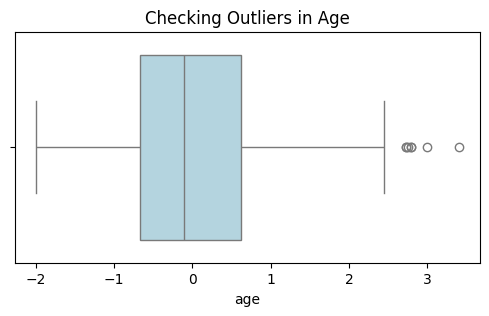

In [265]:


plt.figure(figsize=(6, 3))
sns.boxplot(x=df['age'], color='lightblue')
plt.title('Checking Outliers in Age')
plt.show()


5. Dataset Preparation 

 Separate features (X) and target (y = Survived). • Split data into training and testing sets (80/20, random_state=42). • Use stratification.

In [266]:
X=df.drop('survived',axis=1)
y=df['survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)

 6. Preprocessing Pipeline Build a Scikit-learn pipeline using: • SimpleImputer • ColumnTransformer • OneHotEncoder • StandardScaler 

In [267]:
num_col=['age', 'fare', 'sibsp', 'parch']
cat_col=['sex', 'embarked', 'pclass']
num_transform=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median'),),('scaler',StandardScaler())])


cat_transform=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent'),),('onhot',OneHotEncoder(handle_unknown='ignore',sparse_output=False),),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transform, num_col),
        ('cat', cat_transform, cat_col),
    ]
)

print("--- PREPROCESSING PIPELINE CREATED ---")



--- PREPROCESSING PIPELINE CREATED ---


In [268]:
preproc_matrix = preprocessor.fit_transform(df[num_col + cat_col])
new_columns = preprocessor.get_feature_names_out()
df_clean = pd.DataFrame(preproc_matrix, columns=new_columns)

 7. Validation Ensure: 

• No missing values remain. •

In [269]:
print(df_clean.isnull().sum())

num__age           0
num__fare          0
num__sibsp         0
num__parch         0
cat__sex_0         0
cat__sex_1         0
cat__embarked_0    0
cat__embarked_1    0
cat__embarked_2    0
cat__embarked_3    0
cat__pclass_1      0
cat__pclass_2      0
cat__pclass_3      0
dtype: int64


 All features are numerical. 

In [270]:
df_clean.dtypes.unique()

array([dtype('float64')], dtype=object)

• No data leakage exists. 

In [271]:

X = df[num_col + cat_col]
y = df['survived']  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


X_train_clean = preprocessor.fit_transform(X_train) 
X_test_clean = preprocessor.transform(X_test)       


• Class distribution is preserved. 

In [272]:
# Check karein ki percentage distribution barkarar hai ya nahi
print("\nOriginal Target Distribution:\n", y.value_counts(normalize=True))
print("\nTrain Target Distribution:\n", y_train.value_counts(normalize=True))



Original Target Distribution:
 survived
0    0.58801
1    0.41199
Name: proportion, dtype: float64

Train Target Distribution:
 survived
0    0.588517
1    0.411483
Name: proportion, dtype: float64


 8. Save Outputs Save: • Clean dataset • X_train, X_test • y_train, y_test • Preprocessing pipeline • Deliverables • Jupyter Notebook with preprocessing steps. • Cleaned dataset CSV. • Saved preprocessing pipeline. • Short report explaining cleaning, feature engineering, encoding, and scaling decisions.

In [273]:
df_clean.to_csv('cleaned_dataset.csv', index=False)
print("Clean Titanic data saved Successfully")

Clean Titanic data saved Successfully


In [274]:

cols = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_clean, columns=cols)
X_test_df = pd.DataFrame(X_test_clean, columns=cols)

X_train_df.to_csv('X_train.csv', index=False)
X_test_df.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("All Train test data save")


All Train test data save


In [275]:
import joblib


joblib.dump(preprocessor, 'preprocessing_pipeline.joblib')

print("Preprocessing pipeline (.joblib file) save ")


Preprocessing pipeline (.joblib file) save 
